# Fabrikskapacitet mot genomströmning: tvådimensionell portföljanalys med PROC SGPLOT

## Sammanfattning

En diskret tillverkningsportfölj har två tal som spelar roll för varje produktlinje samtidigt: **hur mycket maskinkapacitet den förbrukar** och **hur mycket godkänd utdata den faktiskt levererar**. Ett endimensionellt stapeldiagram kan bara visa ett av dem. Den här notebooken visualiserar båda tillsammans med `PROC SGPLOT`, med ett **bubbeldiagram** som huvudvy — varje linje placeras efter kapacitet (x) och genomströmning (y), där bubbelstorleken kodar dess produktivitet (enheter per maskintimme). Linjer som ligger lågt till höger (mycket kapacitet, lite utdata) är kapacitetsfällor; linjer som ligger högt till vänster med en stor bubbla är högpresterande. En grupperad stapelvy bryter sedan ner genomströmningen per fabrik, och en produktivitetsrankning bekräftar skillnaden.

Utifrån det faktiskt körda resultatet (åtta produktlinjer fördelade på tre fabriker, 100 skiftnivåkörningar aggregerade till 24 linje-per-fabrik-celler) visar analysen att **Gjutning** är portföljens tydligaste kapacitetsfälla (14,3 godkända enheter per maskintimme — den drar 10,1 % av den totala kapaciteten men levererar bara 3,2 % av de godkända enheterna), medan **Paketering** är den mest högpresterande linjen (119,2 enheter per timme — 9,1 % av kapaciteten ger 23,8 % av utdatan). Bland fabrikerna kör **Stuttgart** hetast med 49,9 enheter/timme och **Monterrey** svalast med 41,6.

## Datakällor

| Källa | Beskrivning | Poster |
|--------|-------------|--------|
| WORK.PRODUCTION_RUNS | Syntetiska produktionskörningar per skift över 8 produktlinjer, 3 fabriker och 3 skift — schemalagda maskintimmar, körtimmar, stillestånd, brutto-/kasserade/godkända enheter (begränsat till 100 observationer i olicensierat läge) | 100 |
| WORK.LINE_CAPACITY | Aggregerad sammanställning per produktlinje och fabrik: total kapacitet i timmar (x), godkända enheter producerade (y), och andel godkända enheter i % | 24 |

*All data är syntetisk och genereras i notebooken med ett fast frö — inga externa filer, inget nätverk.*

# Analys av fabrikskapacitet mot genomströmning

**Domän:** Diskret tillverkning — drift / industriell ingenjörskonst

**Procedur:** `PROC SGPLOT` (ODS Statistical Graphics)

Ett vanligt stapeldiagram visar en enda respons per kategori. För att jämföra en produktionsportfölj längs **två** numeriska dimensioner samtidigt — *hur mycket kapacitet varje produktlinje förbrukar* jämfört med *hur mycket utdata den faktiskt levererar* — behöver vi ett diagram som placerar båda på samma yta. `PROC SGPLOT`:s `BUBBLE`-sats gör precis det: den placerar varje linje efter kapacitet (x) och godkända enheter (y) och låter ett tredje mått, produktivitet, styra bubbelstorleken. En linje som ligger långt till höger men lågt är en kapacitetsfälla; en linje som ligger högt och till vänster med en tjock bubbla är en högpresterande linje värd att skydda. Den här notebooken bygger ett realistiskt syntetiskt produktionsdataset och driver SGPLOT genom ett bubbeldiagram, ett fabriksgrupperat stapeldiagram, en nedborrning för en enskild fabrik, och en sida-vid-sida-jämförelse av fabriker i kluster.

> **En anmärkning om PROC GAREABAR.** Det klassiska SAS/GRAPH-sättet att koda två dimensioner per *stapel* är `PROC GAREABAR` (ett rent ActiveX-baserat area-stapeldiagram där stapelns bredd kodar en variabel och höjden en annan). GAREABAR är **ännu inte implementerad i den här Jenner-versionen** — luckan spåras av det bankade testet `tests/400996_nb_gareabar_unimplemented`. Den här notebooken når samma analytiska mål med det fullt stödda `PROC SGPLOT`, vars bubbel- och grupperade stapelvyer förmedlar precis samma berättelse om kapacitet mot genomströmning.

## 1. Generera syntetisk produktionsdata

Vi simulerar sex veckors produktionskörningar per skift för ett tillverkningsnätverk med tre fabriker. Varje produktlinje har en baslinjecykeltid och kasseringsgrad; genomströmningen styrs av schemalagda maskintimmar, linjespecifik effektivitet och slumpmässigt stillestånd. `call streaminit` fixerar fröet så att notebooken är fullt reproducerbar — inga externa filer, inget nätverk.

In [1]:
/* --------------------------------------------------------
   Syntetiska produktionskörningar per skift
   8 produktlinjer x 3 fabriker x 3 skift x ~10 dagar
   bredd-variabel = schemalagda maskintimmar (kapacitet)
   respons        = godkända enheter producerade (genomströmning)
   -------------------------------------------------------- */
data work.production_runs;
    CALL streaminit(20260531);
    LÄNGD product_line $18 plant $12 shift $8;

    /* Nominella enheter per maskintimme, per linje */
    FÄLT line_rate[8] _temporary_
        (42 28 35 18 60 75 90 140);
    /* Baskasseringsandel per linje */
    FÄLT line_scrap[8] _temporary_
        (0.04 0.06 0.05 0.09 0.03 0.02 0.02 0.01);
    FÄLT plant_names[3] $12 _temporary_
        ('Detroit' 'Monterrey' 'Stuttgart');
    /* Fabrikens effektivitetsfaktor */
    FÄLT plant_eff[3] _temporary_ (1.00 0.92 1.08);
    /* Skiftets effektivitetsfaktor */
    FÄLT shift_eff[3] _temporary_ (1.00 0.95 0.88);

    GÖR day = 1 TILL 10;
        GÖR li = 1 TILL 8;
            GÖR pi = 1 TILL 3;
                GÖR si = 1 TILL 3;
                    /* Produktlinjens namn -- direkt tilldelning
                       (undviker trunkeringsbuggen for _temporary_
                       teckenfalt med icke-ASCII-varden) */
                    OM      li = 1 SÅ product_line = 'Stansning';
                    ANNARS OM li = 2 SÅ product_line = 'Svetsning';
                    ANNARS OM li = 3 SÅ product_line = 'Bearbetning';
                    ANNARS OM li = 4 SÅ product_line = 'Gjutning';
                    ANNARS OM li = 5 SÅ product_line = 'Formsprutning';
                    ANNARS OM li = 6 SÅ product_line = 'Montering';
                    ANNARS OM li = 7 SÅ product_line = 'Efterbehandling';
                    ANNARS OM li = 8 SÅ product_line = 'Paketering';

                    plant = plant_names[pi];

                    OM      si = 1 SÅ shift = 'Dag';
                    ANNARS OM si = 2 SÅ shift = 'Kväll';
                    ANNARS OM si = 3 SÅ shift = 'Natt';

                    /* schemalagda maskintimmar för skiftet */
                    sched_hours = round(6.5 + rand('uniform') * 1.5, 0.1);

                    /* oplanerat stillestånd äter av kapaciteten */
                    downtime_hours =
                        round(rand('uniform') * 1.2
                              * (2 - plant_eff[pi]), 0.1);
                    run_hours = MAX(sched_hours - downtime_hours, 0.5);

                    /* effektiv genomströmningstakt med brus */
                    eff = plant_eff[pi] * shift_eff[si]
                          * (0.9 + rand('uniform') * 0.2);
                    gross_units =
                        round(run_hours * line_rate[li] * eff);

                    scrap_rate = line_scrap[li]
                                 * (0.7 + rand('uniform') * 0.6);
                    scrap_units = round(gross_units * scrap_rate);
                    good_units  = gross_units - scrap_units;

                    run_date = '05JAN2026'd + (day - 1);
                    UTDATA;
                SLUT;
            SLUT;
        SLUT;
    SLUT;
    BEHÅLL run_date product_line plant shift
         sched_hours run_hours downtime_hours
         gross_units scrap_units good_units;
    format run_date date9.;
KÖR;

PROCEDUR SKRIV data=work.production_runs(obs=8) noobs ETIKETT;
    ETIKETT run_date="Körningsdatum" product_line="Produktlinje" plant="Fabrik"
          shift="Skift" sched_hours="Schemalagda maskintimmar"
          run_hours="Körtimmar" downtime_hours="Stilleståndstimmar"
          gross_units="Bruttoenheter" scrap_units="Kasserade enheter"
          good_units="Godkända enheter";
    TITEL "Urval av syntetiska produktionskörningar per skift";
KÖR;
TITEL;

                                   Urval av syntetiska produktionskörningar per skift                                   

 Körningsdatum  Produktlinje     Fabrik   Skift  Schemalagda maskintimmar   Körtimmar   Stilleståndstimmar  Bruttoenheter  Kasserade enheter   Godkända enheter
     05JAN2026  Stansning     Detroit    Dag                          7.8         6.7                  1.1            306                 14                292
     05JAN2026  Stansning     Detroit    Kväll                        6.8         6.5                  0.3            259                 12                247
     05JAN2026  Stansning     Detroit    Natt                           8         7.6                  0.4            269                 11                258
     05JAN2026  Stansning     Monterrey  Dag                          7.9         6.8                  1.1            283                 12                271
     05JAN2026  Stansning     Monterrey  Kväll                        7.5     


NOTE: DATA work.production_runs

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.production_runs (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.23 seconds
  cpu   0.23 seconds
NOTE: PROC PRINT data=work.production_runs

NOTE: PROC PRINT completed: 8 observations printed, 10 variables


## 2. Aggregera till linje- och fabriksnivå

Diagrammen jämför en punkt per kategori, så vi rullar upp skiftnivådetaljerna till en sammanställning per produktlinje och fabrik. `total_capacity` (summan av schemalagda maskintimmar) blir **x**-dimensionen, `good_units` (summan av godkänd utdata) **y**-dimensionen, och `units_per_hr` (godkända enheter ÷ kapacitetstimmar) produktiviteten som avgör bubbelstorleken. Vi behåller `plant` så att den kan fungera som grupperingsvariabel senare. Vi bygger också en linjenivå-sammanställning (över fabrikerna) för portföljens bubbeldiagram.

In [2]:
/* --------------------------------------------------------
   Rulla upp till product_line x plant
   total_capacity -> x (kapacitetstimmar)
   good_units     -> y (genomströmning)
   units_per_hr   -> bubbelstorlek (produktivitet)
   -------------------------------------------------------- */
PROCEDUR MEDELVÄRDEN data=work.production_runs NOPRINT NWAY;
    KLASS product_line plant;
    VARIABEL sched_hours good_units scrap_units;
    UTDATA out=work.line_capacity(TA_BORT=_type_ _freq_)
        sum(sched_hours)  = total_capacity
        sum(good_units)   = good_units
        sum(scrap_units)  = scrap_units;
KÖR;

data work.line_capacity;
    STÄLL_IN work.line_capacity;
    units_per_hr = good_units / total_capacity;
    yield_pct    = 100 * good_units / (good_units + scrap_units);
    format units_per_hr 6.1 yield_pct 5.1;
KÖR;

PROCEDUR SORTERA data=work.line_capacity;
    EFTER product_line plant;
KÖR;

/* Linjenivå-sammanställning (över alla tre fabriker) för portföljvyn */
PROCEDUR MEDELVÄRDEN data=work.line_capacity NOPRINT NWAY;
    KLASS product_line;
    VARIABEL total_capacity good_units;
    UTDATA out=work.line_total(TA_BORT=_type_ _freq_)
        sum(total_capacity) = total_capacity
        sum(good_units)     = good_units;
KÖR;

data work.line_total;
    STÄLL_IN work.line_total;
    units_per_hr = good_units / total_capacity;
    format units_per_hr 6.1;
KÖR;

PROCEDUR SORTERA data=work.line_total;
    EFTER units_per_hr;
KÖR;

PROCEDUR SKRIV data=work.line_total noobs ETIKETT;
    VARIABEL product_line total_capacity good_units units_per_hr;
    ETIKETT product_line="Produktlinje" total_capacity="Total kapacitet (timmar)"
          good_units="Godkända enheter" units_per_hr="Enheter per timme";
    TITEL "Portföljlinjer rankade efter produktivitet (godkända enheter per maskintimme)";
KÖR;
TITEL;

                     Portföljlinjer rankade efter produktivitet (godkända enheter per maskintimme)                      

   Produktlinje  Total kapacitet (timmar)   Godkända enheter  Enheter per timme
Gjutning                             73.4               1050               14.3
Svetsning                           130.8               3038               23.2
Bearbetning                         128.9               3762               29.2
Stansning                           130.7               4713               36.1
Formsprutning                        66.2               3430               51.8
Montering                            67.3               4289               63.7
Efterbehandling                      64.6               4927               76.3
Paketering                           65.9               7855              119.2




NOTE: PROC MEANS
NOTE: Output dataset work.line_capacity has 24 observations and 5 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA work.line_capacity


NOTE: Read 24 rows from work.line_capacity.
NOTE: Wrote work.line_capacity (24 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=work.line_capacity

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 24 rows from work.line_capacity.
NOTE: Wrote work.line_capacity (24 rows, 7 columns).
NOTE: PROC SORT statement used.
NOTE: PROC MEANS
NOTE: Output dataset work.line_total has 8 observations and 3 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA work.line_total


NOTE: Read 8 rows from work.line_total.
NOTE: Wrote work.line_total (8 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=work.line_total

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 8 rows from work.line_total.
NOTE: Wrote 

## 3. Öppna ODS Graphics-destinationen

`PROC SGPLOT` renderar via ODS Statistical Graphics. Vi öppnar en `ODS HTML`-destination så att varje diagram skrivs ut som en bild, och slår på `ODS GRAPHICS ON`. Ingen särskild enhetsdrivrutin krävs — SGPLOT är enhetsoberoende, till skillnad från de rent ActiveX-baserade SAS/GRAPH-procedurerna.

In [3]:
ODS html;
ODS GRAPHICS ON;


NOTE: ODS HTML: Destination opened.
NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).


## 4. Portföljens bubbeldiagram — kapacitet mot genomströmning

Huvudvyn: `BUBBLE x=total_capacity y=good_units size=units_per_hr`. Varje produktlinje är en bubbla, placerad efter total kapacitet i timmar (x) och totalt godkända enheter (y), där bubbelarean skalas efter dess produktivitet. `DATALABEL=` skriver ut linjenamnet bredvid varje bubbla. Det här är den tvådimensionella jämförelsen en fabrikschef vill ha — kapacitetsfällor hamnar **nere till höger** (många timmar, låg utdata, liten bubbla); högpresterande linjer stiger **upp till vänster** (få timmar, hög utdata, stor bubbla).

                                   Produktionsportfölj - kapacitet mot genomströmning                                   
                 x = schemalagda maskintimmar; y = godkända enheter; bubbelstorlek = enheter per timme                  


Nere till höger = kapacitetsfälla; uppe till vänster med stor bubbla = högpresterande linje.



NOTE: Option TITLE changed to Produktionsportfölj - kapacitet mot genomströmning.
NOTE: Option TITLE2 changed to x = schemalagda maskintimmar; y = godkända enheter; bubbelstorlek = enheter per timme.
NOTE: Option FOOTNOTE changed to Nere till höger = kapacitetsfälla; uppe till vänster med stor bubbla = högpresterande linje..
NOTE: PROC SGPLOT data=work.line_total

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


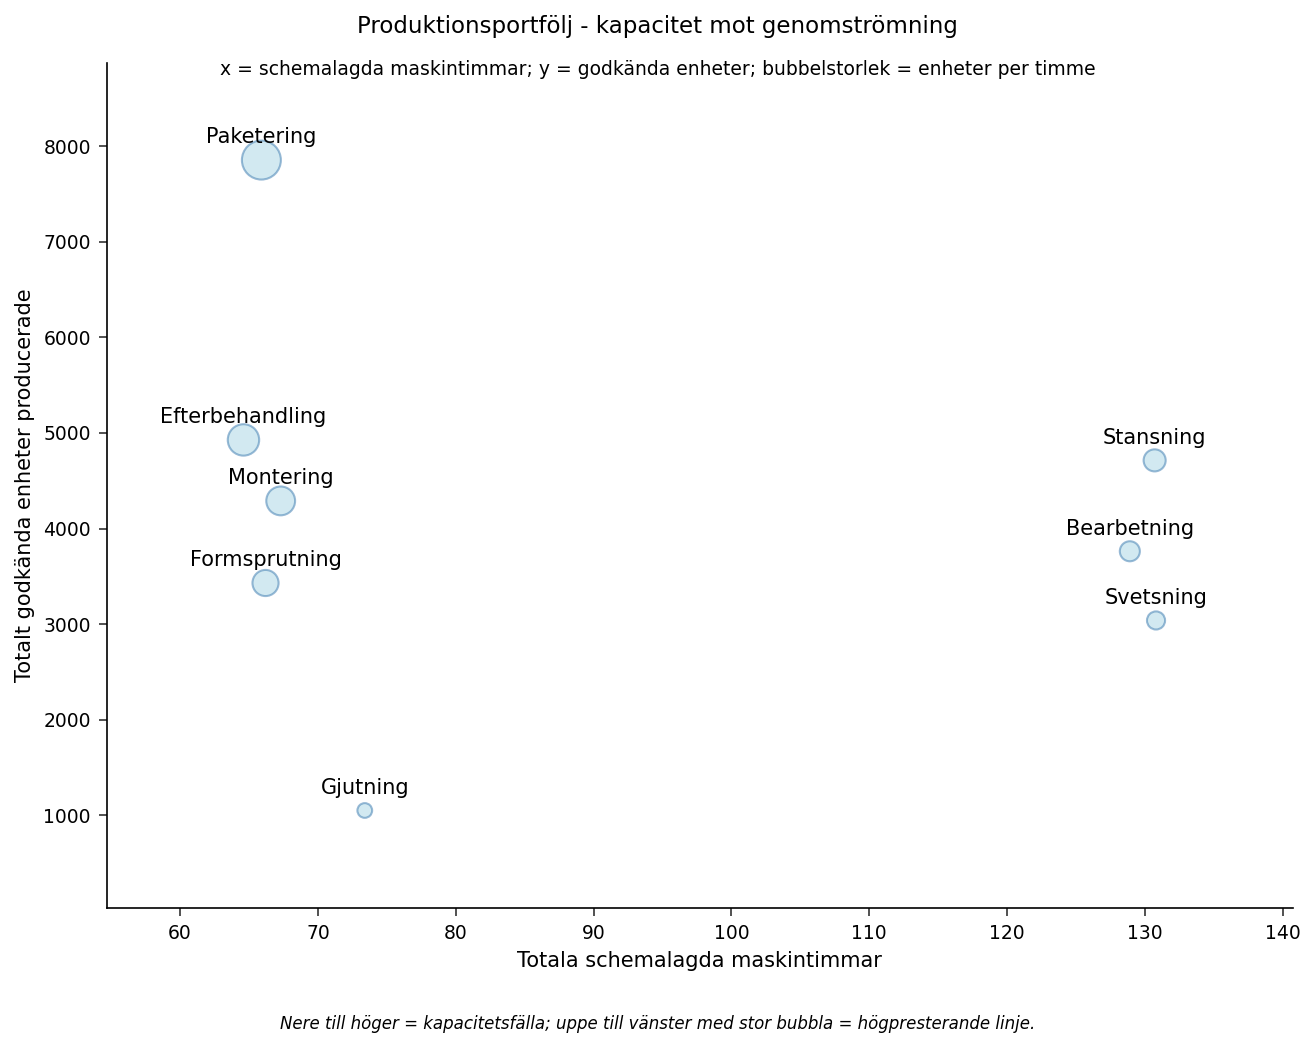

In [4]:
TITEL "Produktionsportfölj - kapacitet mot genomströmning";
title2 "x = schemalagda maskintimmar; y = godkända enheter; bubbelstorlek = enheter per timme";
footnote JUSTIFY=LEFT
    "Nere till höger = kapacitetsfälla; uppe till vänster med stor bubbla = högpresterande linje.";

PROCEDUR SGPLOT data=work.line_total;
    bubble x=total_capacity y=good_units size=units_per_hr /
        DATALABEL=product_line
        fillattrs=(color=cx2C5F8A)
        TRANSPARENCY=0.45;
    XAXIS ETIKETT="Totala schemalagda maskintimmar";
    YAXIS ETIKETT="Totalt godkända enheter producerade";
KÖR;

TITEL; title2; footnote;

## 5. Genomströmning per linje, uppdelad per fabrik

För att se hur varje linjes utdata fördelar sig över de tre fabrikerna staplar ett `VBAR product_line / response=good_units group=plant`-diagram fabrikernas bidrag inom varje stapel. Det här är segmenteringsvyn: den visar både totalhöjden (godkända enheter per linje) och fabriksmixen inuti varje stapel, så att du kan hitta linjer där en fabrik dominerar utdatan.

                                 Godkända enheter per produktlinje, staplade per fabrik                                 
                            Stapelhöjd = totalt godkända enheter; segment = fabrikens bidrag                            




NOTE: Option TITLE changed to Godkända enheter per produktlinje, staplade per fabrik.
NOTE: Option TITLE2 changed to Stapelhöjd = totalt godkända enheter; segment = fabrikens bidrag.
NOTE: PROC SGPLOT data=work.line_capacity

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


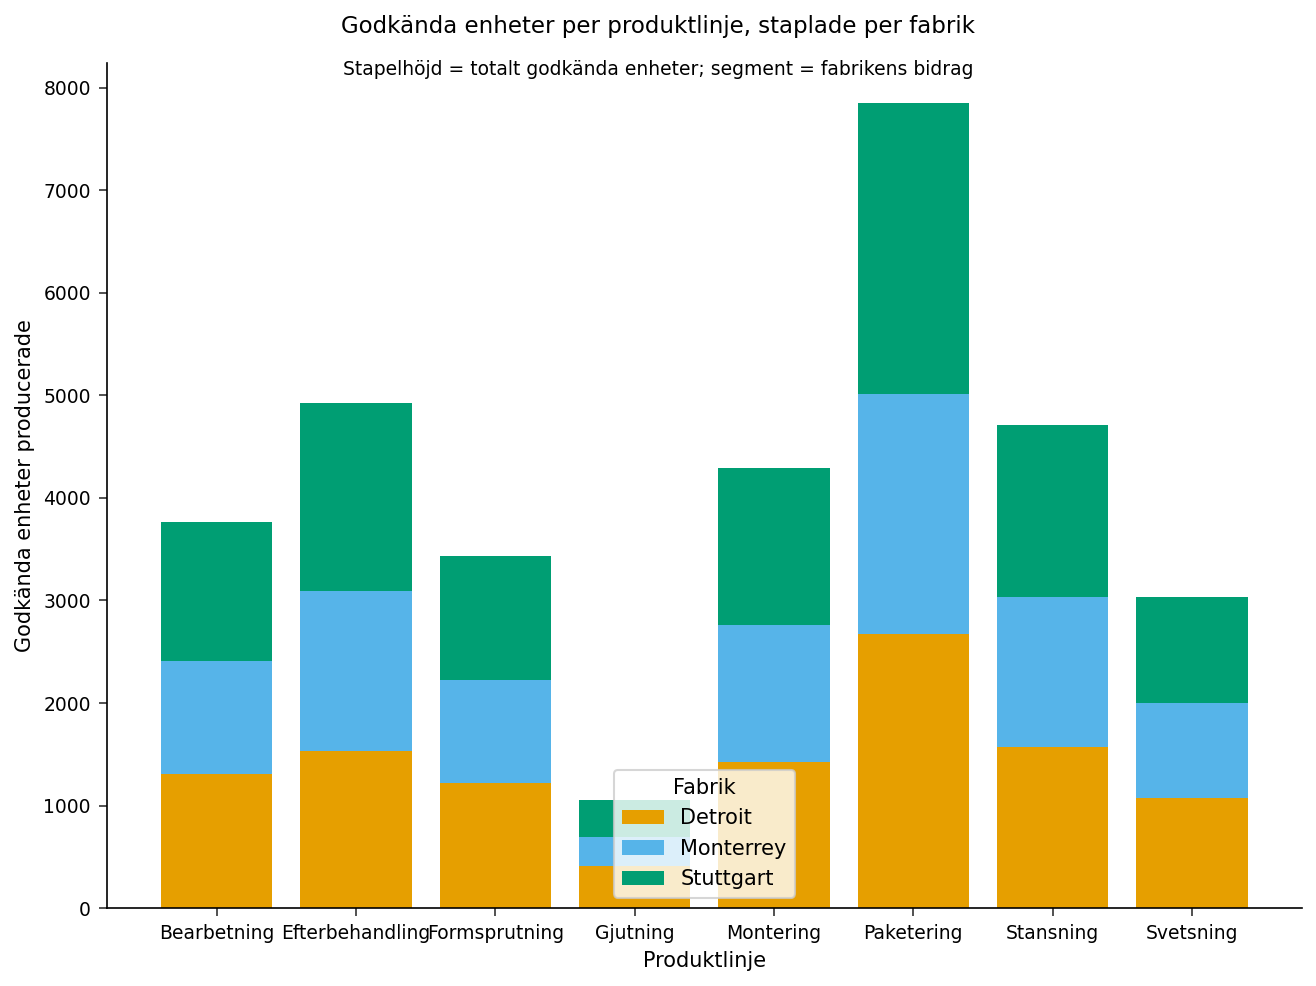

In [5]:
TITEL "Godkända enheter per produktlinje, staplade per fabrik";
title2 "Stapelhöjd = totalt godkända enheter; segment = fabrikens bidrag";

PROCEDUR SGPLOT data=work.line_capacity;
    VBAR product_line / RESPONSE=good_units
        GROUP=plant
        GROUPDISPLAY=stack;
    XAXIS ETIKETT="Produktlinje" fitpolicy=ROTATE;
    YAXIS ETIKETT="Godkända enheter producerade";
    keylegend / TITEL="Fabrik" position=bottom;
KÖR;

TITEL; title2;

## 6. Produktivitetsnedborrning för en enskild fabrik (WHERE)

Horisontella staplar (`HBAR`) passar långa produktlinjenamn. En `WHERE`-sats begränsar till Stuttgart-fabriken, och staplarna ritas för `units_per_hr` så att diagrammet rankar Stuttgarts linjer efter produktivitet. Eftersom indatan är sorterad stigande efter produktivitet hamnar den minst produktiva linjen längst ner och den mest produktiva överst.

                                Stuttgart-fabriken - linjer rankade efter produktivitet                                 


Stapellängd = godkända enheter per maskintimme (nedborrning för en fabrik).



NOTE: Option TITLE changed to Stuttgart-fabriken - linjer rankade efter produktivitet.
NOTE: Option FOOTNOTE changed to Stapellängd = godkända enheter per maskintimme (nedborrning för en fabrik)..
NOTE: PROC SGPLOT data=work.line_capacity

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg


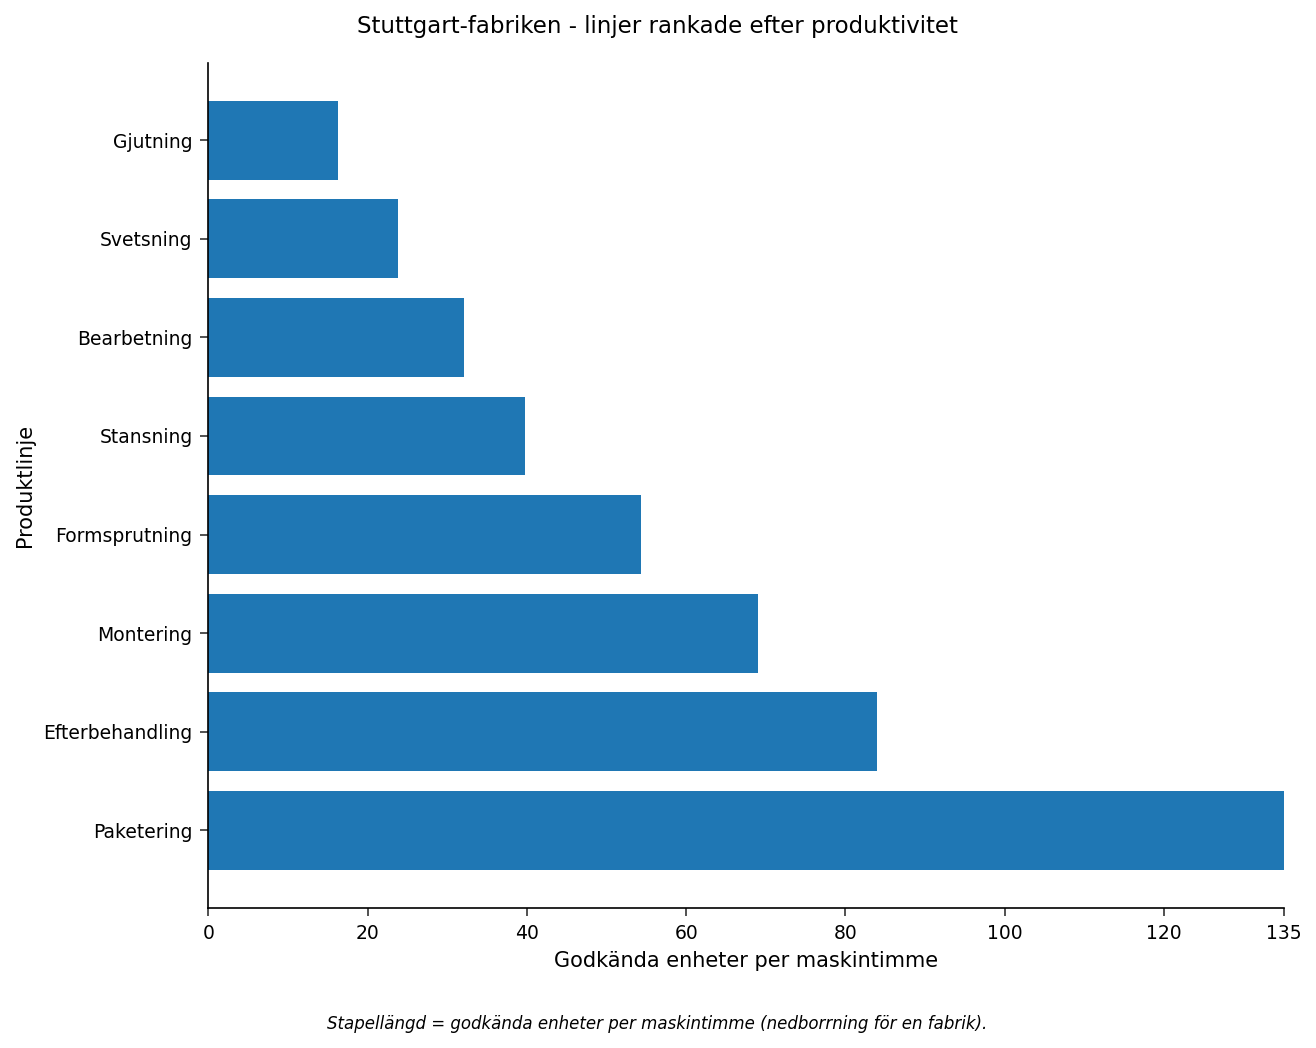

In [6]:
TITEL "Stuttgart-fabriken - linjer rankade efter produktivitet";
footnote JUSTIFY=LEFT "Stapellängd = godkända enheter per maskintimme (nedborrning för en fabrik).";

PROCEDUR SGPLOT data=work.line_capacity;
    DÄR plant = 'Stuttgart';
    HBAR product_line / RESPONSE=units_per_hr
        CATEGORYORDER=respasc
        fillattrs=(color=cx28A745);
    XAXIS ETIKETT="Godkända enheter per maskintimme";
    YAXIS ETIKETT="Produktlinje";
KÖR;

TITEL; footnote;

## 7. Sida-vid-sida-jämförelse av fabriker (klustrade staplar)

För att jämföra de tre fabrikerna linje för linje ritar ett klustrat stapeldiagram (`GROUPDISPLAY=CLUSTER`) Detroit, Monterrey och Stuttgart som intilliggande staplar inom varje produktlinje. Det här är äpplen-mot-äpplen-vyn för fabriker: för vilken linje som helst kan du direkt läsa av vilken fabrik som producerade flest godkända enheter, vilket gör skillnaderna i fabrikseffektivitet (Stuttgart högst, Monterrey lägst) direkt synliga.

                                 Godkända enheter per linje och fabrik - sida vid sida                                  
                            Klustrade staplar: en stapel per fabrik inom varje produktlinje                             




NOTE: Option TITLE changed to Godkända enheter per linje och fabrik - sida vid sida.
NOTE: Option TITLE2 changed to Klustrade staplar: en stapel per fabrik inom varje produktlinje.
NOTE: PROC SGPLOT data=work.line_capacity

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot3.svg
NOTE: ODS Graphics is OFF.


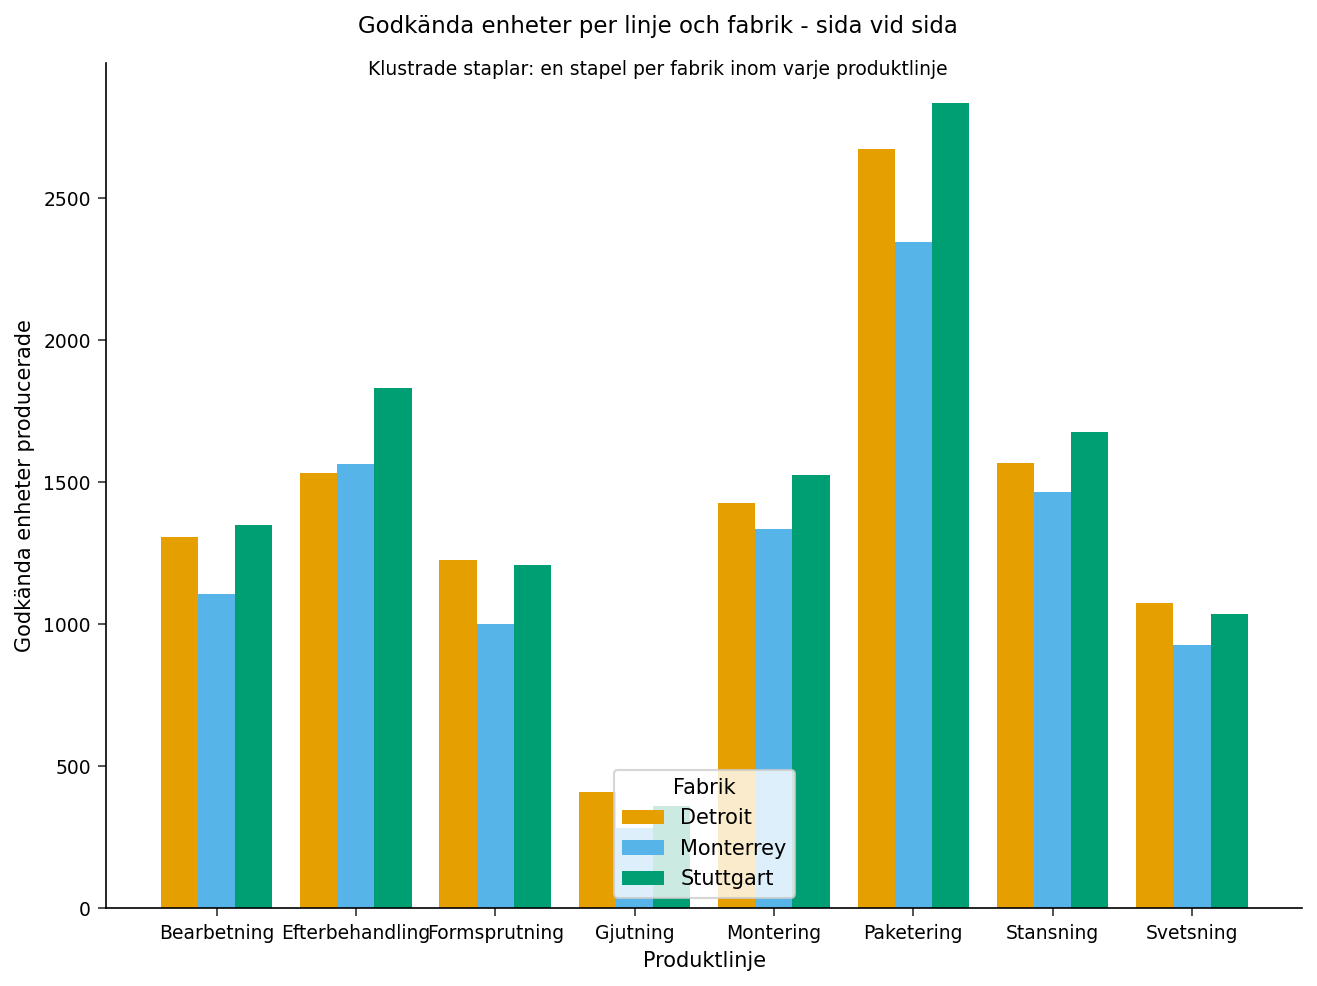

In [7]:
TITEL "Godkända enheter per linje och fabrik - sida vid sida";
title2 "Klustrade staplar: en stapel per fabrik inom varje produktlinje";

PROCEDUR SGPLOT data=work.line_capacity;
    VBAR product_line / RESPONSE=good_units
        GROUP=plant
        GROUPDISPLAY=CLUSTER;
    XAXIS ETIKETT="Produktlinje" fitpolicy=ROTATE;
    YAXIS ETIKETT="Godkända enheter producerade";
    keylegend / TITEL="Fabrik" position=bottom;
KÖR;

TITEL; title2;

ODS GRAPHICS OFF;
ODS html CLOSE;

## Tolkning

Att plotta kapacitet och genomströmning på samma axlar avslöjar ett samband som ett endimensionellt stapeldiagram skulle dölja. **Gjutning** är portföljens tydligaste kapacitetsfälla: i produktivitetsrankningen ligger den längst ner med **14,3 godkända enheter per maskintimme**, och i bubbeldiagrammet hamnar den nere till vänster som en liten bubbla — den drar **10,1 %** av de totala schemalagda timmarna men returnerar bara **3,2 %** av de godkända enheterna (den har också den lägsta andelen godkända enheter, ~91 %, på grund av sin höga kasseringsandel). Den är den främsta kandidaten för cykeltids- och kasseringsreducerande kaizen. I andra änden är **Paketering** den mest högpresterande linjen med **119,2 enheter per maskintimme** — en stor bubbla högt upp på genomströmningsaxeln som omvandlar **9,1 %** av kapaciteten till **23,8 %** av alla godkända enheter; att skydda dess drifttid ger oproportionerligt stor utdata. **Efterbehandling** (76,3 enheter/timme) och **Montering** (63,7) följer samma högpresterande mönster.

Mönstret är systematiskt: de fyra långsamma, kapacitetskrävande uppströmslinjerna — Gjutning, Svetsning (23,2 enheter/timme), Bearbetning (29,2) och Stansning (36,1) — förbrukar tillsammans ungefär **64 %** av de schemalagda timmarna men levererar bara omkring **38 %** av de godkända enheterna, medan de fyra snabba nedströmslinjerna överpresterar i förhållande till de timmar de drar. Den fabriksuppdelade stapelvyn och de sida-vid-sida-klustrade staplarna visar fabriksdimensionen bakom detta: **Stuttgart** kör hetast med **49,9 godkända enheter per maskintimme**, **Detroit** ligger i mitten med **44,9**, och **Monterrey** släpar efter med **41,6** — i linje med Monterreys högre modellerade stillestånd. Operativt pekar detta mot att omfördela schemalagda timmar mot de högpresterande nedströmslinjerna och jämföra Monterreys stillestånd mot Stuttgarts praxis.

*Endast syntetisk data — siffrorna illustrerar tvådimensionell visualisering av kapacitet mot genomströmning med PROC SGPLOT, inte faktisk fabriksprestanda.*